# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from fjsspw_solver import Individual, Encoding

from fjsspw_solver.plotting import plot_fjsspw_gantt

# Plotting

In [2]:
def plot_fjssp_chromosome(os_vector, ms_vector, ws_vector, title: str = "FJSSP-WU Solution Representation (Three-Layer Chromosome)", fontsize: int = 16):
    # Data configuration
    data = [os_vector, ms_vector, ws_vector]
    labels = ['Operation    \nSequence (OS)', 'Machine    \nSelection (MS)', 'Worker      \nSelection (WS)']
    # labels = ['OS', 'MS', 'WS']
    colors = ["#f8b6b6", "#b9dbfd", "#cefdce"] # Soft Red, Blue, Green
    
    num_genes = len(os_vector)
    num_layers = len(data)

    fig, ax = plt.subplots(figsize=(10, 4))

    # Create the grid
    for row in range(num_layers):
        for col in range(num_genes):
            # Draw a rectangle for each gene
            rect = plt.Rectangle((col, num_layers - row - 1), 1, 1, 
                                 facecolor=colors[row], edgecolor='black', linewidth=1.5)
            ax.add_patch(rect)
            
            # Add the value text in the center of the box
            ax.text(col + 0.5, num_layers - row - 0.5, str(data[row][col]), fontsize=fontsize, fontweight='bold',
                    va='center', ha='center')

    # Formatting the axes
    ax.set_xlim(0, num_genes)
    ax.set_ylim(0, num_layers)
    
    # Set Y-axis labels to the Vector Names
    ax.set_yticks(np.arange(num_layers) + 0.5)
    ax.set_yticklabels(labels[::-1], fontweight='bold', fontsize=fontsize)
    
    # Set X-axis labels to Gene Indices
    ax.set_xticks(np.arange(num_genes) + 0.5)
    ax.set_xticklabels([f'Gene {i+1}' for i in range(num_genes)], fontweight='bold', fontsize=fontsize)
    
    # Remove top and right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Add a descriptive title
    # plt.title(title, pad=20, fontweight='bold', fontsize=fontsize)
    
    plt.tight_layout()
    plt.show()

# Example Toy Data

In [3]:
# durations[operation][machine][worker]
durations = [
    # Job 1 Op 1 (O1,1)
    [
        [2, 2],
        [4, 4] 
    ],
    
    # Job 1 Op 2 (O1,2)
    [
        [-1, 2],
        [-1, -1]
    ],
    
    # Job 2 Op 1 (O2,1)
    [
        [5, 5],
        [3, 3] 
    ],
    
    # Job 2 Op 2 (O2,2)
    [
        [2, -1],
        [-1, -1] 
    ]
]
job_sequence = [0, 0, 1, 1]

encoding = Encoding(
    durations,
    job_sequence
)

indv = Individual(encoding)
# indv.random_init()
indv.sequence = [0, 1, 0, 1]
indv.machines = [0, 0, 1, 0]
indv.workers = [0, 1, 1, 0]

In [4]:
sequence, machines, workers, start_times, end_times = indv.get_representation()
sequence, machines, workers, start_times, end_times

([0, 1, 0, 1], [0, 0, 1, 0], [0, 1, 1, 0], [0, 3, 0, 5], [2, 5, 3, 7])

# Plots

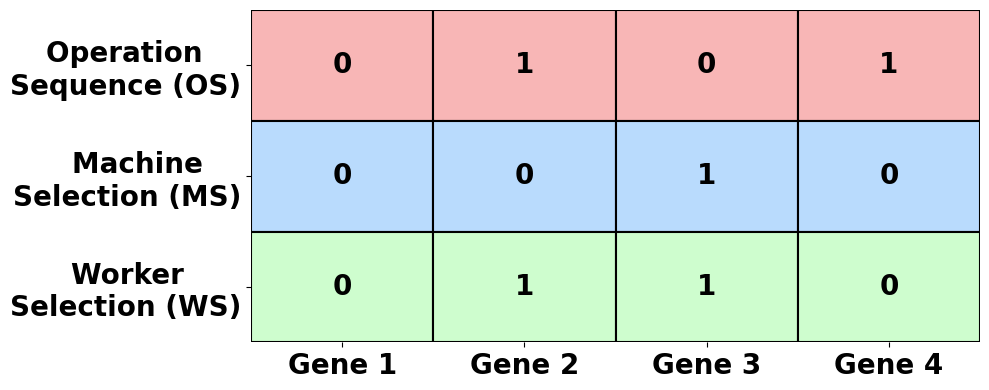

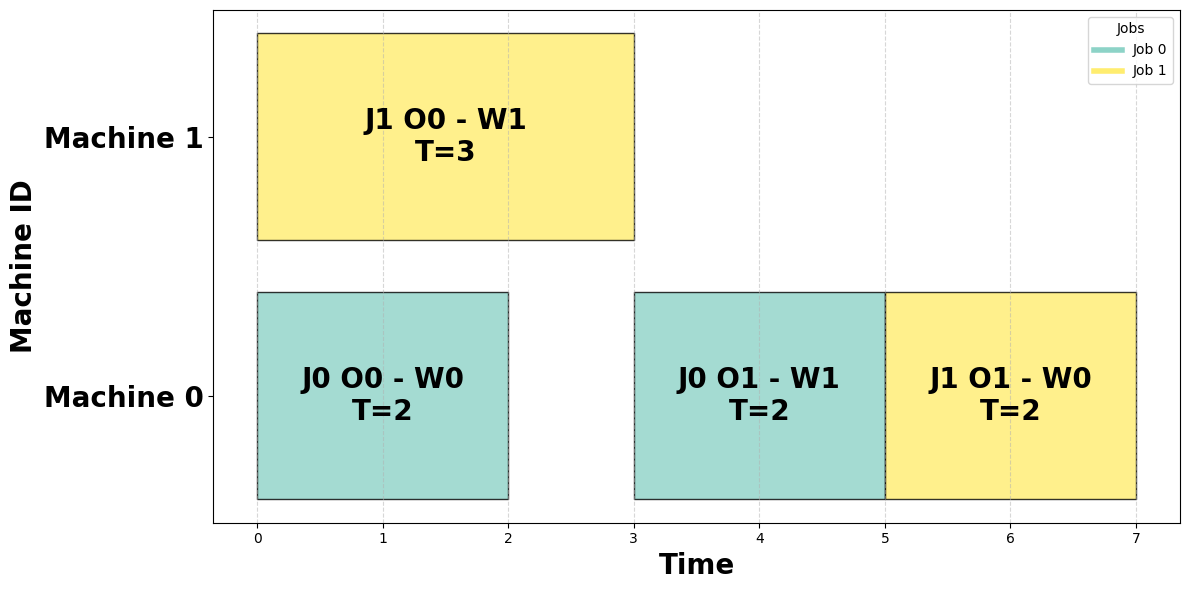

In [5]:
plot_fjssp_chromosome(sequence, machines, workers, title="Toy example chromosome", fontsize=20)
plot_fjsspw_gantt(sequence, machines, workers, start_times, end_times, encoding=encoding,
                  instance_name="Toy example schedule and assignments", fontsize=20, fontweight="bold",
                  show_title=False)